In [1]:
#from data_quality_test_management import *
from recipe_management import *
from dotenv import load_dotenv
import os
# Charger les variables du fichier .env
load_dotenv()
from rapidfuzz import fuzz, process
import re





ModuleNotFoundError: No module named 'recipe_management'

In [2]:
OPENROUTER_API_KEY = os.getenv('OPENROUTER_API_KEY_2')
MODEL_NAME = os.getenv('MODEL_NAME_2')

In [35]:
#graph_rec = pd.read_csv("dataset_finaux/final_dataset_cleaned_with_non_gestures.csv")
data = pd.read_csv("dataset_finaux/dataset_final.csv")


In [67]:
def normalize_surface(text):
    text = str(text).lower().strip()
    text = text.replace("-", " ")
    text = re.sub(r"\s+", " ", text)
    return text
def is_similar(a, b, threshold=95):
    return fuzz.token_sort_ratio(a, b) >= threshold

def is_similar_any(target, choices, threshold=95):
    match, score, _ = process.extractOne(
        target, choices, scorer=fuzz.token_sort_ratio
    )
    return score >= threshold
def clean_action_list_robust_fuzzy(
    actions,
    actions_to_remove,
    normalization_dict,
    similarity_threshold=95
):
    # normalisation préalable des règles
    removal_norm = [normalize_surface(a) for a in actions_to_remove]

    norm_map = {
        normalize_surface(k): normalize_surface(v)
        for k, v in normalization_dict.items()
    }

    cleaned = []
    actions_list = to_list_of_strings(actions)

    for a in actions_list:
        a_norm = normalize_surface(a)

        # 1️⃣ normalisation via dictionnaire (fuzzy)
        for k, v in norm_map.items():
            if is_similar_any(a_norm, k, similarity_threshold):
                a_norm = v
                break

        # 2️⃣ suppression via fuzzy matching
        remove = False
        for r in removal_norm:
            if is_similar_any(a_norm, r, similarity_threshold):
                remove = True
                break

        if remove:
            continue

        cleaned.append(a_norm)

    return cleaned


In [2]:
df = pd.read_csv("dataset_finaux/final_dataset_cleaned_with_non_gestures.csv")

In [3]:
df

,id,title,actions,type,type_2
0,000018c8a5,Worlds Best Mac and Cheese,"['preheat', 'butter', 'cook', 'clean', 'place'...",principal,variante_principale
1,000033e39b,Dilly Macaroni Salad Recipe,"['cook', 'drain', 'mix', 'blend', 'add', 'toss...",principal,variante_principale
2,000033e39b,Dilly Macaroni Salad Recipe,"['cook', 'drain', 'cube', 'slice', 'mince', 'm...",secondaire,variante_ingredients
3,000035f7ed,Gazpacho,"['puree', 'mix', 'chill', 'drizzle', 'garnish']",principal,variante_principale
4,000035f7ed,Gazpacho,"['quarter', 'cut', 'puree', 'mix', 'chop', 'ch...",secondaire,variante_ingredients
...,...,...,...,...,...
2669151,fe6081549d,Southeast Asian Slow Cooked Winter Vegetables,"['toss', 'whisk', 'pour', 'cover', 'cook', 'se...",principal,variante_principale
2669152,fe6081549d,Southeast Asian Slow Cooked Winter Vegetables,"['cut', 'toss', 'whisk', 'pour', 'cover', 'coo...",secondaire,variante_ingredients
2669153,fe6081549d,Southeast Asian Slow Cooked Winter Vegetables,"['toss', 'whisk', 'pour', 'cover', 'cook', 'se...",secondaire,variante_permutation
2669154,fe60c0c72b,Black Olive Pesto for Pizza,['blend'],principal,variante_principale


In [4]:
df,df1 = data_cleaning_3stages(df)

→ Nettoyage de la colonne actions...

Nettoyage de la colonne 'actions'...
✅ Nettoyage terminé!
  ✓ Nettoyage terminé: 4,047,815 lignes
→ Netoyage et Normalisation des verbes...
  ✓ Netoyage et Normalisation terminée
→ Création d'une copie pour data_with_non_gesture...
  ✓ Copie créée: 4,047,815 lignes
→ Filtrage des gestes...
  ✓ Filtrage terminé
→ Suppression des doublons consécutifs...
  ✓ Doublons consécutifs supprimés
→ Suppression des doublons par ID...
  ✓ final_df: 1,846,041 doublons supprimés (2,201,774 restantes)
  ✓ data_with_gesture: 1,378,520 doublons supprimés (2,669,295 restantes)
→ Suppression des lignes avec actions vides...
  ✓ final_df: 7,207 lignes vides supprimées
  ✓ data_with_gesture: 139 lignes vides supprimées
→ Tri des données...
  ✓ Tri terminé
final_df (gestes uniquement): 2,194,567 lignes
data_with_gesture (tous verbes): 2,669,156 lignes


In [19]:
2669156 / 100000

26.69156

In [14]:
df["actions"] = df["actions"].apply(
             to_list_of_strings #lambda lst: clean_action_list_1(lst, actions_to_remove, normalization_dict)
        )

In [15]:
i  = 11

In [31]:
batch_size = 100000
batch_data = df[i:i+batch_size]
i += batch_size
batch_data

,id,title,actions,type,type_2
700011,3f6224a9d2,Sweet Fuyu Persimmon Salad,"[toast, cool, fold, refrigerate]",principal,variante_principale
700012,3f6224a9d2,Sweet Fuyu Persimmon Salad,"[peel, cut, chop, toast, cool, fold, refrigerate]",secondaire,variante_ingredients
700013,3f6224a9d2,Sweet Fuyu Persimmon Salad,"[peel, cut, toast, chop, cool, fold, refrigerate]",secondaire,variante_permutation
700014,3f6224a9d2,Sweet Fuyu Persimmon Salad,"[toast, peel, cut, chop, cool, fold, refrigerate]",secondaire,variante_permutation
700015,3f6234e723,Lime Pie,"[heat, break, mix, taste, mix, add, mix, fold,...",principal,variante_principale
...,...,...,...,...,...
800006,466d93863c,Corn Flake Cookies I,"[preheat, grease, mix, beat, mix, beat, stir, ...",secondaire,variante_permutation
800007,466db3d2d3,Emily's Marinated Venison Steaks,"[whisk, brush, squeeze, marinate, preheat, oil...",principal,variante_principale
800008,466db3d2d3,Emily's Marinated Venison Steaks,"[whisk, marinate, preheat, oil, remove, cook]",secondaire,variante_permutation
800009,466db3d2d3,Emily's Marinated Venison Steaks,"[preheat, whisk, marinate, oil, remove, cook]",secondaire,variante_permutation


In [85]:
# Appliquer la transformation qui force au bon format puis nettoyer


# Vérifier verbes uniques après nettoyage
def extraire_verbes_uniques_from_col(df, col="actions"):
    s = set()
    for x in df[col].values:
        if not x:
            continue
        for tok in x:
            s.add(tok)
    return sorted(s)

verbes_apres = extraire_verbes_uniques_from_col(df, "actions")
print("nombre verbes après nettoyage:", len(verbes_apres))
print(verbes_apres[:100])   # premiers 100 pour contrôle
with open('echantillon_verbes_uniques.txt', 'w', encoding='utf-8') as f:
    for verbe in verbes_apres:
        f.write(verbe + '\n')

nombre verbes après nettoyage: 1971
['', 'absorb', 'accompany', 'acidulate', 'activate', 'add', 'add tvp', 'adhere', 'adjust', 'aerate', 'age', 'agitate', 'air-dry', 'air-fry', 'airtight', 'al', 'almond', 'alternate', 'amalgamate', 'anoint', 'another', 'apply', 'arrange', 'assemble', 'attach', 'autolyse', 'bag', 'baggie', 'bain-marie', 'bait', 'bake', 'balls', 'baptize', 'bar', 'barbecue', 'barely', 'base', 'baseline', 'bast', 'bathe', 'batten', 'batter', 'bbq', 'beard', 'beat', 'behead', 'bhoona', 'bias-cut', 'bias-slice', 'bind', 'blacken', 'blanch', 'blanket', 'blast', 'blaze', 'blend', 'blended', 'blenderize', 'blind-bake', 'blister', 'blitz', 'blob', 'blot', 'blow', 'boil', 'boils', 'bone', 'braid', 'braise', 'bread', 'break', 'break down', 'brew', 'brine', 'bring', 'broil', 'brown', 'brownie', 'bruise', 'brulee', 'brunoise', 'brush', 'bubble', 'buff', 'bundle', 'bung', 'burn', 'burnish', 'burst', 'butcher', 'butter', 'butterfly', 'can', 'candy', 'cap', 'caramelize', 'carbonate', 

In [100]:
verbes_apres = extraire_verbes_uniques_from_col(data_cleaned, "actions")
print("nombre verbes après nettoyage:", len(verbes_apres))
print(verbes_apres[:100])   # premiers 100 pour contrôle
with open('echantillon_verbes_uniques.txt', 'w', encoding='utf-8') as f:
    for verbe in verbes_apres:
        f.write(verbe + '\n')

nombre verbes après nettoyage: 693
['', 'absorb', 'acidulate', 'activate', 'add', 'adhere', 'adjust', 'aerate', 'age', 'agitate', 'air fry', 'airtight', 'alternate', 'amalgamate', 'anoint', 'apply', 'arrange', 'assemble', 'attach', 'autolyse', 'bag', 'baggie', 'bake', 'ball', 'bar', 'barbecue', 'bast', 'baste', 'bathe', 'batten', 'batter', 'beard', 'beat', 'behead', 'bind', 'blacken', 'blanch', 'blanket', 'blast', 'blaze', 'blend', 'blended', 'blenderize', 'blister', 'blitz', 'blob', 'blot', 'blow', 'boil', 'bone', 'bottle', 'braid', 'braise', 'bread', 'break', 'brew', 'brine', 'bring', 'broil', 'brown', 'bruise', 'brunoise', 'brush', 'brûlée', 'bubble', 'buff', 'bundle', 'bung', 'burn', 'burnish', 'burst', 'butcher', 'butter', 'butterfly', 'can', 'candy', 'cap', 'caramelize', 'carbonate', 'carve', 'cavity', 'center', 'char', 'check', 'chiffonade', 'chill', 'chink', 'chip', 'chisel', 'choke', 'chop', 'chuck', 'chunk', 'churn', 'clarify', 'claw', 'clean', 'clear', 'cleave', 'clip']


In [98]:
data_cleaned

,id,title,actions,type,type_2
0,000018c8a5,Worlds Best Mac and Cheese,"[preheat, butter, cook, clean, place, mix, scr...",principal,variante_principale
1,000033e39b,Dilly Macaroni Salad Recipe,"[cook, drain, mix, blend, add, toss, refrigera...",principal,variante_principale
2,000033e39b,Dilly Macaroni Salad Recipe,"[cook, drain, cube, slice, mince, mix, blend, ...",secondaire,variante_ingredients
3,000035f7ed,Gazpacho,"[puree, mix, chill, drizzle, garnish]",principal,variante_principale
4,000035f7ed,Gazpacho,"[quarter, cut, puree, mix, chop, chill, drizzl...",secondaire,variante_ingredients
...,...,...,...,...,...
2669151,fe6081549d,Southeast Asian Slow Cooked Winter Vegetables,"[toss, whisk, pour, cover, cook, separate, gar...",principal,variante_principale
2669152,fe6081549d,Southeast Asian Slow Cooked Winter Vegetables,"[cut, toss, whisk, pour, cover, cook, separate...",secondaire,variante_ingredients
2669153,fe6081549d,Southeast Asian Slow Cooked Winter Vegetables,"[toss, whisk, pour, cover, cook, separate, gar...",secondaire,variante_permutation
2669154,fe60c0c72b,Black Olive Pesto for Pizza,[blend],principal,variante_principale


In [62]:
set(verbes_apres) & set(cles)

{'pressure cook', 'punch down'}

In [97]:
if __name__ == "__main__":
    # 3️⃣ NETTOIE (ULTRA RAPIDE!)
    data = df.copy()
    data_cleaned = clean_dataframe_optimized(
        data=data,
        actions_to_remove=actions_to_remove,
        normalization_dict=normalization_dict,
        similarity_threshold=95,  # Tu peux ajuster entre 85-95
        verbose=True
    )
    
  

🚀 Début du nettoyage optimisé...
   Dataset: 2,669,156 lignes
   Actions à supprimer: 1023
   Règles de normalisation: 477
   Seuil de similarité: 95

📋 Étape 1/3: Extraction des actions uniques...
   ✓ 1,971 actions uniques trouvées

🧹 Étape 2/3: Nettoyage des actions uniques...
   ✓ 1,115 actions conservées
   ✓ 856 actions supprimées (43.4%)

⚡ Étape 3/3: Application du mapping...

✅ Terminé en 275.99 secondes!
   Vitesse: 9,671 lignes/seconde

📊 Statistiques:
   Actions moyennes AVANT: 11.26
   Actions moyennes APRÈS: 11.24
   Réduction: 0.2%


In [ ]:

#data["actions_fixed"] = data["actions"].apply(to_list_of_strings)
data["actions_cleaned"] = data["actions"].apply(
lambda lst: clean_action_list_robust_fuzzy(lst, actions_to_remove, normalization_dict)
 )

KeyboardInterrupt: 

In [95]:
with open('actions_to_remove_final.txt', 'r', encoding='utf-8') as f:
   actions_to_remove = [line.strip() for line in f if line.strip()]

    # Importer normalization_dict depuis le fichier JSON
with open('normalization_dict_final.json', 'r', encoding='utf-8') as f:
    normalization_dict = json.load(f)

In [ ]:
   # 1. Nettoyer la colonne actions
print("→ Nettoyage de la colonne actions...")
df = clean_actions_column(df)
print(f"  ✓ Nettoyage terminé: {len(df):,} lignes")
        
        
        # 2. netoyage et Normalisation des verbes (vectorisé si possible)
print("→ Netoyage et Normalisation des verbes...")
def to_list_of_strings(x):
    """Retourne une liste de strings propre pour une cellule actions."""
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
        except Exception:
            # si ce n'est pas une repr de liste, on en fait une liste avec la string
            return [x]
        else:
            return to_list_of_strings(parsed)
    if isinstance(x, list):
        # aplatir une couche si éléments sont listes
        flattened = []
        for e in x:
            if isinstance(e, list):
                flattened.extend(e)
            else:
                flattened.append(e)
        return [str(i) for i in flattened]
    # autre type scalaire
    return [str(x)]

→ Nettoyage de la colonne actions...

Nettoyage de la colonne 'actions'...
✅ Nettoyage terminé!
  ✓ Nettoyage terminé: 2,099,782 lignes
→ Netoyage et Normalisation des verbes...


In [12]:
import ast
import numpy as np

def to_list_of_strings(x):
    """Retourne une liste de strings propre pour une cellule actions."""
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return []
    if isinstance(x, np.ndarray):
        x = x.tolist()
    if isinstance(x, str):
        try:
            parsed = ast.literal_eval(x)
        except Exception:
            # si ce n'est pas une repr de liste, on en fait une liste avec la string
            return [x]
        else:
            return to_list_of_strings(parsed)
    if isinstance(x, list):
        # aplatir une couche si éléments sont listes
        flattened = []
        for e in x:
            if isinstance(e, list):
                flattened.extend(e)
            else:
                flattened.append(e)
        return [str(i) for i in flattened]
    # autre type scalaire
    return [str(x)]

def clean_action_list_robust(actions, actions_to_remove, normalization_dict):
    # préparer versions normalisées des règles : tout en lowercase et stripped
    removal_set = {a.strip().lower() for a in actions_to_remove}
    # normalization_dict_map : clés en lower/strip, valeurs en lower/strip
    norm_map = {k.strip().lower(): v.strip().lower() for k, v in normalization_dict.items()}

    cleaned = []
    # garantir qu'on travaille sur une liste de strings
    actions_list = to_list_of_strings(actions)

    for a in actions_list:
        # normaliser token de base
        a_clean = str(a).strip().lower()
        # appliquer normalization (si existe)
        if a_clean in norm_map:
            a_clean = norm_map[a_clean]
        # ignorer si dans removal
        if a_clean in removal_set:
            continue
        cleaned.append(a_clean)   # si tu veux garder case originale, stocke la version originale transformée
    return cleaned


In [90]:
print(len(actions_to_remove))
print(len(normalization_dict))

1023
477


In [53]:
i = 5
batch_size = 100000
batch = data[i:i+batch_size]
i += batch_size

verb = extraire_verbes_uniques_from_col(batch, "actions_cleaned")
verb[:100]

['absorb',
 'activate',
 'add',
 'adhere',
 'adjust',
 'aerate',
 'age',
 'agitate',
 'alternate',
 'apply',
 'arrange',
 'assemble',
 'attach',
 'bake',
 'barbecue',
 'beard',
 'beat',
 'bind',
 'blacken',
 'blanch',
 'blanket',
 'blend',
 'blitz',
 'blot',
 'blow',
 'boil',
 'bone',
 'braid',
 'braise',
 'break',
 'brew',
 'brine',
 'bring',
 'broil',
 'brown',
 'bruise',
 'brunoise',
 'brush',
 'bubble',
 'bundle',
 'burn',
 'burst',
 'butter',
 'butterfly',
 'cap',
 'caramelize',
 'carve',
 'center',
 'char',
 'check',
 'chiffonade',
 'chill',
 'chip',
 'chop',
 'chuck',
 'chunk',
 'churn',
 'clarify',
 'clean',
 'clear',
 'clip',
 'cluster',
 'coat',
 'color',
 'cook',
 'cool',
 'cork',
 'cover',
 'crack',
 'crank',
 'cream',
 'create',
 'crimp',
 'crisp',
 'cross',
 'crosscut',
 'crosshatch',
 'crumb',
 'crumble',
 'crumple',
 'crunch',
 'crush',
 'crust',
 'cube',
 'cure',
 'curl',
 'curve',
 'cut',
 'dampen',
 'dash',
 'decant',
 'decorate',
 'decrease',
 'defrost',
 'deglaze',

In [42]:
cles = list(normalization_dict.keys())

In [49]:
act =  set(cles) - set(verbes_apres) 


In [56]:
act  = set(actions_to_remove) - set(act)
act = set(act) - set(verb)
with open('echantillon_verbes_uniques.txt', 'w', encoding='utf-8') as f:
    for verbe in act:
        f.write(verbe + '\n')

In [ ]:
import json

# Sauvegarder actions_to_remove dans un fichier texte
with open('actions_to_remove.txt', 'w', encoding='utf-8') as f:
    for action in actions_to_remove:
        f.write(f"{action}\n")

# Sauvegarder normalization_dict dans un fichier JSON
with open('normalization_dict.json', 'w', encoding='utf-8') as f:
    json.dump(normalization_dict, f, ensure_ascii=False, indent=2)

print("✅ Fichiers sauvegardés :")
print("  - actions_to_remove.txt")
print("  - normalization_dict.json")

✅ Fichiers sauvegardés :
  - actions_to_remove.txt
  - normalization_dict.json


In [ ]:
df.to_csv('dataset_finaux/dataset_final.csv', index=False)
df1.to_csv('dataset_finaux/dataset_temporel_final.csv', index=False)
    

In [ ]:
import ast

# Étape 1 : Convertir les strings en vraies listes
graph_rec['actions'] = graph_rec['actions'].apply(ast.literal_eval)
graph_rec['actions_cleaned'] = graph_rec['actions'].apply(
    lambda actions: clean_action_list(actions, actions_to_remove, normalization_dict)
)

✅ Fichiers sauvegardés :
  - actions_to_remove.txt
  - normalization_dict.json


In [ ]:
with open('ma_liste_actions.txt', 'w', encoding='utf-8') as f:
    items_per_line = 5
    for i in range(0, len(actions_uniques), items_per_line):
        line_items = actions_uniques[i:i+items_per_line]
        f.write(', '.join(line_items) + '\n')
   

In [ ]:
# EXEMPLE D'UTILISATION :

if __name__ == "__main__":
    
    chemin = "Instructions_segments_treated/Instructions_segment_{}.csv"  # Remplacez par votre chemin
    actions_uniques = extraire_actions_depuis_fichiers(
        chemin_pattern=chemin,
        num_min=1,
        num_max=100
    )
    

In [ ]:




if __name__ == "__main__":
    
    df_recettes =  graph_rec  #pd.read_csv("dataset_finaux/final_dataset_cleaned_with_non_gestures.csv")

    
    print("\n=== EXEMPLE 6 : Vérification de plusieurs actions ===")
    actions_a_verifier = ['bring to a boil', 'bring to a bubble', 'bring to a near-boil', 'bring to a simmer', 'bring to boil',
                        'bring to boiling', 'bring to pressure', 'bring to room temperature', 'bring to simmer', 'bring to soft ball stage'
                        'bring to the boil', 'bring together', 'bring up',]
    for action in actions_a_verifier:
        existe = rechercher_recettes_par_action(df_recettes, action)
        statut = "✓ Trouvée" if existe else "✗ Non trouvée"
        print(f"{statut} : '{action}'")


=== EXEMPLE 6 : Vérification de plusieurs actions ===
✓ Trouvée : 'bring to a boil'
✓ Trouvée : 'bring to a bubble'
✗ Non trouvée : 'bring to a near-boil'
✓ Trouvée : 'bring to a simmer'
✓ Trouvée : 'bring to boil'
✓ Trouvée : 'bring to boiling'
✗ Non trouvée : 'bring to pressure'
✓ Trouvée : 'bring to room temperature'
✓ Trouvée : 'bring to simmer'
✗ Non trouvée : 'bring to soft ball stagebring to the boil'
✓ Trouvée : 'bring together'
✗ Non trouvée : 'bring up'


In [ ]:
# Chemins des fichiers
RECIPES_CSV = "recipes.csv"
RECIPE_INSTRUCTIONS_CSV = "recipe_instructions.csv"
RECIPE_INGREDIENTS_CSV = "recipe_ingredients.csv"
GRAPHS_RECIPES_CSV = "dataset_finaux/dataset_final_version_2.csv"
    

recipes_df = pd.read_csv("recipes.csv")
recipe_instructions_df = pd.read_csv("recipe_instructions.csv")
recipe_ingredients_df = pd.read_csv("recipe_ingredients.csv")
    

In [ ]:
import pandas as pd

def extraire_actions_depuis_fichiers(chemin_pattern, num_min, num_max, respect_casse=True):
    """
    Charge des dataframes depuis des fichiers et extrait les actions uniques.
    
    Args:
        chemin_pattern: Pattern du chemin (ex: "data/recettes_{}.csv" où {} sera remplacé par le numéro)
        num_min: Numéro minimum du dataframe (ex: 1)
        num_max: Numéro maximum du dataframe (ex: 100)
        respect_casse: Si True, 'Couper' et 'couper' sont différents. Si False, tout en minuscules.
    
    Returns:
        Liste triée d'actions uniques
    """
    actions_uniques = set()
    fichiers_non_trouves = []
    
    for i in range(num_min, num_max + 1):
        try:
            chemin = chemin_pattern.format(i)
            df = pd.read_csv(chemin)
            
            if 'actions' in df.columns:
                actions = df['actions'].dropna().astype(str)
                
                if not respect_casse:
                    actions = actions.str.lower()
                
                actions_uniques.update(actions)
            else:
                print(f"⚠️ Colonne 'actions' non trouvée dans {chemin}")
                
        except FileNotFoundError:
            fichiers_non_trouves.append(chemin)
            continue
        except Exception as e:
            print(f"❌ Erreur lors de la lecture de {chemin}: {str(e)}")
            continue
    
    if fichiers_non_trouves:
        print(f"\n⚠️ {len(fichiers_non_trouves)} fichier(s) non trouvé(s)")
    
    print(f"✓ {num_max - num_min + 1 - len(fichiers_non_trouves)} fichiers traités avec succès")
    
    return sorted(list(actions_uniques))


# EXEMPLE D'UTILISATION :

if __name__ == "__main__":
    # Créer un dataframe d'exemple
    df_recettes = pd.DataFrame({
        'id': [1, 2, 3, 4, 5],
        'title': ['Soupe de légumes', 'Pâtes carbonara', 'Salade César', 'Poulet rôti', 'Tarte aux pommes'],
        'actions': [
            ['chop', 'boil', 'season'],
            ['boil', 'mix', 'cook'],
            ['chop', 'mix', 'Toss'],  # Notez la majuscule sur 'Toss'
            ['season', 'roast', 'baste'],
            ['peel', 'chop', 'bake']
        ]
    })
    
    print("=== EXEMPLE 1 : Extraction avec respect de la casse ===\n")
    actions_avec_casse = extraire_actions_uniques(df_recettes, respect_casse=True)
    print(f"Actions uniques trouvées ({len(actions_avec_casse)}):")
    for action in actions_avec_casse:
        print(f"  - {action}")
    
    print("\n\n=== EXEMPLE 2 : Extraction sans respect de la casse ===\n")
    actions_sans_casse = extraire_actions_uniques(df_recettes, respect_casse=False)
    print(f"Actions uniques trouvées ({len(actions_sans_casse)}):")
    for action in actions_sans_casse:
        print(f"  - {action}")
    
    print("\n\n=== EXEMPLE 3 : Avec des actions en format string ===\n")
    # Simuler un CSV chargé où les listes sont des strings
    df_recettes_str = pd.DataFrame({
        'id': [1, 2, 3],
        'title': ['Soupe', 'Pâtes', 'Salade'],
        'actions': [
            "['chop', 'boil', 'season']",  # Format string
            "['boil', 'mix', 'cook']",
            "['chop', 'mix', 'toss']"
        ]
    })
    
    actions_str = extraire_actions_uniques(df_recettes_str, respect_casse=False)
    print(f"Actions extraites depuis strings ({len(actions_str)}):")
    for action in actions_str:
        print(f"  - {action}")
    
    print("\n\n=== EXEMPLE 4 : Utilisation pour charger depuis des fichiers ===\n")
    # Si vous voulez charger depuis des fichiers CSV :
    # actions_all = extraire_actions_depuis_fichiers("data/recettes_{}.csv", 1, 100)
    print("Pour charger depuis des fichiers, utilisez :")
    print("actions = extraire_actions_depuis_fichiers('data/recettes_{}.csv', 1, 100)")
    
    print("\n\n=== EXEMPLE 5 : Combiner plusieurs dataframes ===\n")
    df1 = pd.DataFrame({'actions': [['chop', 'boil'], ['mix']]})
    df2 = pd.DataFrame({'actions': [['bake', 'chop'], ['season']]})
    
    # Combiner les actions de plusieurs dataframes
    all_actions = set()
    all_actions.update(extraire_actions_uniques(df1, respect_casse=False))
    all_actions.update(extraire_actions_uniques(df2, respect_casse=False))
    
    print(f"Actions combinées de plusieurs dataframes ({len(all_actions)}):")
    for action in sorted(all_actions):
        print(f"  - {action}")

           id        type                                            actions
0  02266aadbd   principal  ['mix', 'add', 'mix', 'add', 'add', 'mix', 'po...
1  02266aadbd  secondaire  ['shred', 'mix', 'add', 'mix', 'add', 'add', '...
2  02266aadbd  secondaire  ['mix', 'add', 'add', 'mix', 'add', 'mix', 'po...
3  02266aadbd  secondaire  ['mix', 'add', 'mix', 'add', 'add', 'mix', 'to...
4  00ffdd1746   principal  ['grease', 'mix', 'blend', 'mix', 'blend', 'fo...


In [ ]:
df = graphs_recipes_df.iloc[0:100] 

In [ ]:
if __name__ == "__main__":

    # Configuration
   
    NB_RECETTES = 2  # Paramétrable
    
        
  
    
    # Exécuter le pipeline
    run_strategy_1_pipeline(
        recipes_df= recipes_df,
        recipe_instructions_df=recipe_instructions_df,
        recipe_ingredients_df= recipe_ingredients_df,
        graphs_recipes_df= df,
        api_key=OPENROUTER_API_KEY,
        nb_recettes=NB_RECETTES,
        output_dir="strategy_1_results",
        random_state=42
    )


################################################################################
# PIPELINE STRATÉGIE 1 - VALIDATION PAR ANNOTATIONS MANUELLES
# Nombre de recettes : 2
################################################################################

  ✅ Recettes : 1029720
  ✅ Instructions : 10666639
  ✅ Ingrédients : 9605394
  ✅ Graphes : 100

ÉTAPE 2/6 : Échantillonnage stratifié...

ÉCHANTILLONNAGE STRATIFIÉ - 2 recettes

Recettes disponibles avec graphes : 25

Distribution cible par complexité :
  SIMPLE: 1 recettes (50.0%)
  MOYENNE: 0 recettes (0.0%)
  COMPLEXE: 1 recettes (50.0%)

✅ Échantillonnage terminé : 2 recettes sélectionnées

Répartition par complexité :
complexity_category
COMPLEXE    1
SIMPLE      1
Name: count, dtype: int64

Répartition par type de cuisine :
cuisine_type
autre    2
Name: count, dtype: int64

Recettes avec ingrédients pré-transformés :
  Oui: 2
  Non: 0

ÉTAPE 3/6 : Génération du fichier Excel pour annotation manuelle...

CRÉATION DU FICHIER EXCEL D'AN

In [ ]:
# Charger le fichier de métriques détaillées généré par le pipeline
metrics_df = pd.read_csv('strategy_1_results/comparison_metrics_detailed.csv')

# Générer toutes les visualisations
generate_all_visualizations(metrics_df, output_dir='strategy_1_results')


GÉNÉRATION DE TOUTES LES VISUALISATIONS

✅ Graphique radar sauvegardé : strategy_1_results\radar_metrics_comparison.png
✅ Graphique de distribution sauvegardé : strategy_1_results\change_categories_distribution.png
✅ Graphique par complexité sauvegardé : strategy_1_results\accuracy_by_complexity.png
✅ Graphique de Levenshtein sauvegardé : strategy_1_results\levenshtein_distribution.png
✅ Graphique des longueurs sauvegardé : strategy_1_results\sequence_length_comparison.png
✅ Heatmap de corrélation sauvegardée : strategy_1_results\metrics_correlation_heatmap.png
✅ Graphique waterfall sauvegardé : strategy_1_results\improvement_waterfall.png
✅ Graphique par type de cuisine sauvegardé : strategy_1_results\cuisine_type_performance.png
⚠️  Plotly non installé. Installation requise : pip install plotly

✅ TOUTES LES VISUALISATIONS GÉNÉRÉES
Total de graphiques créés : 8
Répertoire : strategy_1_results/


['strategy_1_results\\radar_metrics_comparison.png',
 'strategy_1_results\\change_categories_distribution.png',
 'strategy_1_results\\accuracy_by_complexity.png',
 'strategy_1_results\\levenshtein_distribution.png',
 'strategy_1_results\\sequence_length_comparison.png',
 'strategy_1_results\\metrics_correlation_heatmap.png',
 'strategy_1_results\\improvement_waterfall.png',
 'strategy_1_results\\cuisine_type_performance.png']

In [ ]:

if __name__ == "__main__":
   
    
    # Chemins des fichiers
    RECIPES_CSV = "recipes.csv"
    GRAPHS_RECIPES_CSV = "dataset_finaux/dataset_final.csv"
    GRAPHS_CLEANED_WITH_GESTURES_CSV = "dataset_finaux/final_dataset_cleaned_with_non_gestures.csv"
    GRAPHS_CLEANED_WITHOUT_GESTURES_CSV = "dataset_finaux/final_dataset_cleaned_without_non_gestures.csv"
    
    # Exécuter le pipeline
    run_strategy_2_pipeline(
        recipes_csv=RECIPES_CSV,
        graphs_recipes_csv=GRAPHS_RECIPES_CSV,
        graphs_cleaned_with_gestures_csv=GRAPHS_CLEANED_WITH_GESTURES_CSV,
        graphs_cleaned_without_gestures_csv=GRAPHS_CLEANED_WITHOUT_GESTURES_CSV,
        output_dir="strategy_2_results"
    )


################################################################################
# PIPELINE STRATÉGIE 2 - VALIDATION STRUCTURELLE (VERSION AMÉLIORÉE)
################################################################################

📂 CHARGEMENT DES DONNÉES...
  ✅ Recettes: 1,029,720
  ✅ Graphes bruts: 1,927,083
  ✅ Graphes nettoyés (avec): 1,428,496
  ✅ Graphes nettoyés (sans): 1,157,608

🏷️  CLASSIFICATION DES RECETTES...
  ✅ Colonne 'category' ajoutée
     Distribution : {'other': 475684, 'bakery': 285774, 'quick_prep': 165490, 'stew': 102772}
  ✅ Colonne 'complexity' ajoutée
     Distribution : {'simple': 624238, 'moyenne': 327087, 'elevee': 78395}
  ✅ Recipes enrichi sauvegardé : strategy_2_results\recipes_enriched.csv

EXÉCUTION DU TEST 1 SUR LES 3 DATASETS

🔷 TEST 1 - DATASET BRUT (AVANT NETTOYAGE)

TEST 1 : CALCUL DE LA TAILLE DES LISTES D'ACTIONS

📊 STATISTIQUES GLOBALES
--------------------------------------------------------------------------------
Total graphes: 1,927,083
L

In [ ]:
test= pd.read_csv('strategy_2_results/dataset_synthese.csv')

📊 Génération du Graphique 2 : Complexité × Variantes

📂 Chargement des données...
  ✅ Dataset D3 chargé : 1,157,608 graphes
  ✅ Recipes enrichi chargé : 1,029,720 recettes

🔧 Préparation des données...
  ✅ Longueurs calculées (graphes non-vides : 1,157,608)
  ✅ Jointure effectuée : 1,157,608 graphes avec complexité

  Colonnes disponibles : ['id', 'title', 'actions', 'type', 'type_2', 'length', 'complexity']
  Variantes uniques : ['variante_principale' 'variante_ingredients' 'variante_permutation']
  Complexités uniques : ['elevee' 'simple' 'moyenne']

📈 Calcul des statistiques par complexité et variante...
  ✅ Statistiques calculées pour 9 groupes

  Aperçu des statistiques :
complexity         variant_type  count      mean      std  median  min  max
    elevee variante_ingredients  22798 18.326783 7.150883    17.0    1  113
    elevee variante_permutation  28814 17.202853 6.850008    16.0    2   87
    elevee  variante_principale  36803 16.354536 6.788813    15.0    1  111
   moyenne

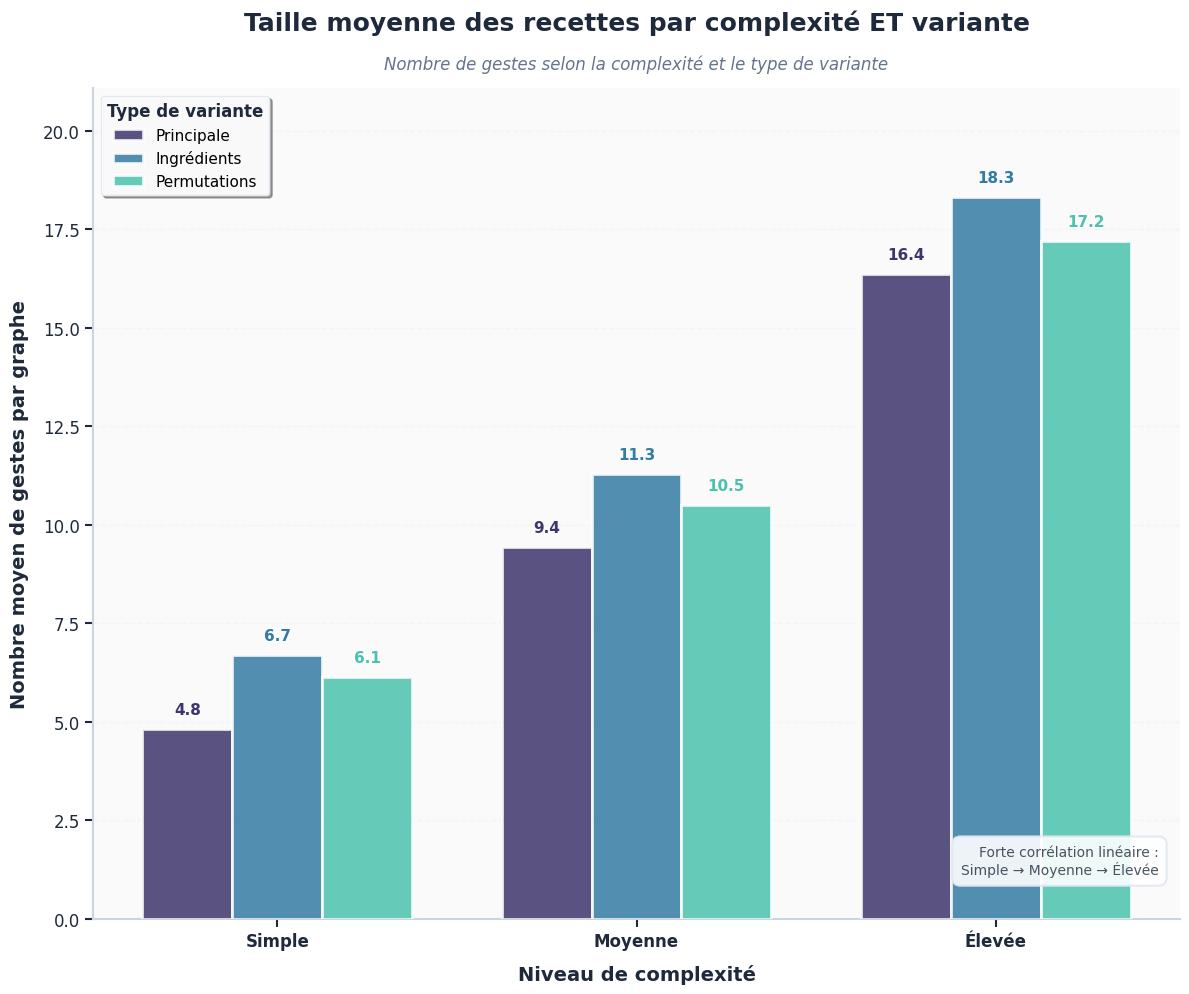


🎉 Graphique 2 généré avec succès !


In [ ]:
"""
Graphique 2 : Taille Moyenne par Complexité et Variante (Dataset D3)
Visualise la corrélation entre complexité des recettes et nombre de gestes
"""

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib.patches import Rectangle

def create_graph_2_complexity_variants(
    graphs_d3_csv: str,
    recipes_enriched_csv: str,
    output_path='graphique_2_complexity_variants.png',
    dpi=300,
    figsize=(12, 10)
):
    """
    Génère le graphique montrant la taille moyenne des graphes par complexité et variante.
    
    Paramètres:
    -----------
    graphs_d3_csv : str
        Chemin vers le fichier CSV du dataset D3 (gestes uniquement)
        Doit contenir: id, variant_type, actions_list
    recipes_enriched_csv : str
        Chemin vers recipes_enriched.csv
        Doit contenir: id, complexity
    output_path : str
        Chemin de sauvegarde du fichier PNG
    dpi : int
        Résolution de l'image (300 recommandé pour impression A0)
    figsize : tuple
        Taille de la figure en pouces
    
    Returns:
    --------
    fig, ax : matplotlib figure and axes
    stats_df : DataFrame avec les statistiques calculées
    """
    
    print("📊 Génération du Graphique 2 : Complexité × Variantes")
    print("="*60)
    
    # ============================================
    # CHARGEMENT DES DONNÉES
    # ============================================
    
    print("\n📂 Chargement des données...")
    
    # Charger D3 (gestes uniquement)
    graphs_d3 = pd.read_csv(graphs_d3_csv)
    print(f"  ✅ Dataset D3 chargé : {len(graphs_d3):,} graphes")
    
    # Charger recipes enrichi
    recipes = pd.read_csv(recipes_enriched_csv)
    print(f"  ✅ Recipes enrichi chargé : {len(recipes):,} recettes")
    
    # ============================================
    # PRÉPARATION DES DONNÉES
    # ============================================
    
    print("\n🔧 Préparation des données...")
    
    # Calculer la longueur de chaque graphe
    def calculate_length(actions_str):
        """Calcule la longueur d'une liste d'actions"""
        try:
            if pd.isna(actions_str) or actions_str == '[]':
                return 0
            # Compter les virgules + 1 (ou parser le JSON)
            import json
            actions = json.loads(actions_str.replace("'", '"'))
            return len(actions)
        except:
            # Méthode alternative si parsing échoue
            if isinstance(actions_str, str):
                return actions_str.count(',') + 1 if ',' in actions_str else 1
            return 0
    
    graphs_d3['length'] = graphs_d3['actions'].apply(calculate_length)
    
    # Filtrer les graphes vides
    graphs_d3 = graphs_d3[graphs_d3['length'] > 0].copy()
    print(f"  ✅ Longueurs calculées (graphes non-vides : {len(graphs_d3):,})")
    
    # Jointure avec recipes pour obtenir la complexité
    graphs_with_complexity = graphs_d3.merge(
        recipes[['id', 'complexity']],
        on='id',
        how='inner'
    )
    
    print(f"  ✅ Jointure effectuée : {len(graphs_with_complexity):,} graphes avec complexité")
    
    # Vérifier les colonnes
    print(f"\n  Colonnes disponibles : {list(graphs_with_complexity.columns)}")
    print(f"  Variantes uniques : {graphs_with_complexity['type_2'].unique()}")
    print(f"  Complexités uniques : {graphs_with_complexity['complexity'].unique()}")
    
    # ============================================
    # CALCUL DES STATISTIQUES
    # ============================================
    
    print("\n📈 Calcul des statistiques par complexité et variante...")
    
    # Grouper par complexity et variant_type
    stats = graphs_with_complexity.groupby(['complexity', 'type_2'])['length'].agg([
        ('count', 'count'),
        ('mean', 'mean'),
        ('std', 'std'),
        ('median', 'median'),
        ('min', 'min'),
        ('max', 'max')
    ]).reset_index()
    stats = stats.rename(columns={'type_2': 'variant_type'})
    print(f"  ✅ Statistiques calculées pour {len(stats)} groupes")
    print("\n  Aperçu des statistiques :")
    print(stats.to_string(index=False))
    
    # ============================================
    # PRÉPARATION POUR VISUALISATION
    # ============================================
    
    # Ordre des complexités
    complexity_order = ['simple', 'moyenne', 'elevee']
    complexity_labels = {
        'simple': 'Simple',
        'moyenne': 'Moyenne',
        'elevee': 'Élevée'
    }
    
    # Ordre des variantes
    variant_order = ['variante_principale', 'variante_ingredients', 'variante_permutation']
    variant_labels = {
        'variante_principale': 'Principale',
        'variante_ingredients': 'Ingrédients',
        'variante_permutation': 'Permutations'
    }
    
    # Créer un pivot table pour faciliter le plotting

    pivot_data = {}
    for variant in variant_order:
        pivot_data[variant] = []
        for complexity in complexity_order:
            mask = (stats['complexity'] == complexity) & (stats['variant_type'] == variant)
            if mask.any():
                pivot_data[variant].append(stats[mask]['mean'].values[0])
            else:
                pivot_data[variant].append(0)
    
    print("\n  Données pivotées pour visualisation :")
    for variant, values in pivot_data.items():
        print(f"  {variant}: {values}")
    
    # ============================================
    # PALETTE DE COULEURS - Mako de Seaborn
    # ============================================
    
    # Obtenir la palette mako avec 3 couleurs
    mako_colors = sns.color_palette("mako", n_colors=3)
    
    colors = {
        'variante_principale': mako_colors[0],      # Couleur mako 1
        'variante_ingredients': mako_colors[1],     # Couleur mako 2
        'variante_permutation': mako_colors[2],     # Couleur mako 3
        'bg': '#FAFAFA',                            # Fond très clair (gris très pâle)
        'text': '#1E293B',                          # Texte gris foncé
        'grid': '#E2E8F0',                          # Grille gris clair
        'spine': '#CBD5E1'                          # Axes gris moyen
    }
    
    print(f"\n  🎨 Palette mako appliquée : {len(mako_colors)} couleurs")
    
    # ============================================
    # CRÉATION DE LA FIGURE
    # ============================================
    
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    ax.set_facecolor(colors['bg'])
    
    # ============================================
    # BARRES GROUPÉES
    # ============================================
    
    # Paramètres des barres
    x = np.arange(len(complexity_order))  # Positions des groupes
    width = 0.25  # Largeur de chaque barre
    
    # Créer les barres pour chaque variante
    bars_dict = {}
    
    for i, (variant, label) in enumerate(zip(variant_order, 
                                              [variant_labels[v] for v in variant_order])):
        offset = (i - 1) * width  # Décalage pour centrer les groupes
        
        bars = ax.bar(
            x + offset,
            pivot_data[variant],
            width,
            label=label,
            color=colors[variant],
            edgecolor='white',
            linewidth=2,
            alpha=0.85,
            zorder=3
        )
        
        bars_dict[variant] = bars
        
        # Ajouter les valeurs sur les barres
        for j, (bar, value) in enumerate(zip(bars, pivot_data[variant])):
            if value > 0:
                height = bar.get_height()
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    height + 0.3,
                    f'{value:.1f}',
                    ha='center',
                    va='bottom',
                    fontsize=11,
                    fontweight='bold',
                    color=colors[variant]
                )
    
    # ============================================
    # LABELS ET TITRES
    # ============================================
    
    # Labels de l'axe X
    ax.set_xticks(x)
    ax.set_xticklabels(
        [complexity_labels[c] for c in complexity_order],
        fontsize=14,
        fontweight='bold',
        color=colors['text']
    )
    
    # Label de l'axe Y
    ax.set_ylabel(
        'Nombre moyen de gestes par graphe',
        fontsize=14,
        fontweight='bold',
        color=colors['text'],
        labelpad=10
    )
    
    # Label de l'axe X
    ax.set_xlabel(
        'Niveau de complexité',
        fontsize=14,
        fontweight='bold',
        color=colors['text'],
        labelpad=10
    )
    
    # Titre principal
    ax.text(
        0.5, 1.08,
        'Taille moyenne des recettes par complexité ET variante',
        transform=ax.transAxes,
        ha='center',
        va='center',
        fontsize=18,
        fontweight='bold',
        color=colors['text']
    )
    
    # Sous-titre
    ax.text(
        0.5, 1.03,
        'Nombre de gestes selon la complexité et le type de variante',
        transform=ax.transAxes,
        ha='center',
        va='center',
        fontsize=12,
        color='#64748B',
        style='italic'
    )
    
    # ============================================
    # LÉGENDE
    # ============================================
    
    legend = ax.legend(
        loc='upper left',
        fontsize=11,
        frameon=True,
        fancybox=True,
        shadow=True,
        framealpha=0.95,
        edgecolor=colors['grid'],
        facecolor='white',
        title='Type de variante',
        title_fontsize=12
    )
    legend.get_title().set_fontweight('bold')
    legend.get_title().set_color(colors['text'])
    
    # ============================================
    # GRILLE ET STYLE
    # ============================================
    
    # Grille horizontale
    ax.grid(
        axis='y',
        alpha=0.3,
        color=colors['grid'],
        linestyle='--',
        linewidth=1,
        zorder=1
    )
    
    # Limites Y
    max_value = max([max(values) for values in pivot_data.values()])
    ax.set_ylim(0, max_value * 1.15)
    
    # Axes
    for spine in ['top', 'right']:
        ax.spines[spine].set_visible(False)
    
    ax.spines['left'].set_color(colors['spine'])
    ax.spines['left'].set_linewidth(1.5)
    
    ax.spines['bottom'].set_color(colors['spine'])
    ax.spines['bottom'].set_linewidth(1.5)
    
    # Couleur des ticks
    ax.tick_params(
        axis='both',
        colors=colors['text'],
        labelsize=12,
        length=6,
        width=1.5
    )
    
    # ============================================
    # ANNOTATIONS SUPPLÉMENTAIRES
    # ============================================
    
    # Annotation : Corrélation
    correlation_text = (
        f"Forte corrélation linéaire :\n"
        f"Simple → Moyenne → Élevée"
    )
    
    ax.text(
        0.98, 0.05,
       # correlation_text,
        transform=ax.transAxes,
        ha='right',
        va='bottom',
        fontsize=10,
        color=colors['text'],
        alpha=0.8,
        bbox=dict(
            boxstyle='round,pad=0.6',
            facecolor='white',
            edgecolor=colors['grid'],
            linewidth=1.5,
            alpha=0.9
        )
    )
    
    # ============================================
    # SAUVEGARDE
    # ============================================
    
    plt.tight_layout()
    plt.savefig(
        output_path,
        dpi=dpi,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )
    
    print(f"\n✅ Graphique 2 sauvegardé : {output_path}")
    print(f"   Résolution : {dpi} DPI")
    print(f"   Dimensions : {figsize[0]}x{figsize[1]} pouces")
    
    # Afficher les statistiques finales
    print(f"\n📊 Résumé des statistiques :")
    for complexity in complexity_order:
        print(f"\n  {complexity_labels[complexity]} :")
        for variant in variant_order:
            mask = (stats['complexity'] == complexity) & (stats['variant_type'] == variant)
            if mask.any():
                row = stats[mask].iloc[0]
                print(f"    • {variant_labels[variant]}: {row['mean']:.2f} ± {row['std']:.2f} gestes")
    
    return fig, ax, stats


# ============================================
# EXEMPLE D'UTILISATION
# ============================================

if __name__ == "__main__":
    # Chemins des fichiers
    graphs_d3_csv = 'dataset_finaux/final_dataset_cleaned_without_non_gestures.csv'
    recipes_enriched_csv = 'strategy_2_results/recipes_enriched.csv'
    
    # Générer le graphique
    fig, ax, stats = create_graph_2_complexity_variants(
        graphs_d3_csv=graphs_d3_csv,
        recipes_enriched_csv=recipes_enriched_csv,
        output_path='strategy_2_results/graphique_2_complexity_variants.png',
        dpi=300,
        figsize=(12, 10)
    )
    
    plt.show()
    print("\n🎉 Graphique 2 généré avec succès !")